# Filtro colaborativo

In [ ]:
!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/1fca0045b0a71004903177bd963ec7410b3f41e1/data/anime.csv


--2025-11-03 02:16:45--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/1fca0045b0a71004903177bd963ec7410b3f41e1/data/anime.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14194341 (14M) [text/plain]
Saving to: ‘anime.csv.1’

anime.csv.1         100%[===================>]  13.54M  --.-KB/s    in 0.07s   

2025-11-03 02:16:45 (182 MB/s) - ‘anime.csv.1’ saved [14194341/14194341]



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import torch



1,2,3)

In [ ]:
class AnimeBuscador:

  def __init__(self, anime_path = '/content/anime.csv', model_name = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'):
    self.anime_df = pd.read_csv(anime_path)

    self.anime_df['title'] = self.anime_df['title'].astype(str).fillna('') # Asegurar strings y manejar NaNs
    self.anime_titles = self.anime_df['title'].tolist() # Lista de títulos para embedding

    self.model = SentenceTransformer(model_name)
    preprocessed_titles = [self.preprocess_text(title) for title in self.anime_titles]
    self.title_embeddings = self.model.encode(preprocessed_titles, show_progress_bar=True, convert_to_tensor=True)

  def preprocess_text(self, text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()  # Unificar espacios
    return text

  def get_embedding(self,text):
    preprocessed_text = self.preprocess_text(text)
    return self.model.encode(preprocessed_text, convert_to_tensor=True)

  def similitud_coseno(self, query_embedding, item_embeddings):
    # Convertir a numpy para el cálculo si son tensores
    if isinstance(query_embedding, torch.Tensor):
        query_embedding = query_embedding.cpu().numpy()
    if isinstance(item_embeddings, torch.Tensor):
        item_embeddings = item_embeddings.cpu().numpy()

    # Asegurarse de que query_embedding sea 1D para el cálculo de norma
    if query_embedding.ndim == 2:
        query_embedding = query_embedding.flatten() # Convertir (1, N) a (N,)

    # Calcular producto punto (item_embeddings . query_embedding)
    dot_product = np.dot(item_embeddings, query_embedding)

    # Calcular las normas
    norm_query = np.linalg.norm(query_embedding)
    norm_items = np.linalg.norm(item_embeddings, axis=1) # Norma para cada fila (item)

    # Evitar división por cero
    similitudes = dot_product / (norm_query * norm_items + 1e-10)
    return similitudes

# Función de búsqueda
  def search_anime(self,query, k=15):

    query_embedding = self.get_embedding(query)
    similarities = self.similitud_coseno(query_embedding, self.title_embeddings)

    # Obtener top k índices (los k mayores, en orden descendente)
    top_k_indices = np.argsort(similarities)[::-1][:k]

    results = []
    for i in top_k_indices:
        anime_info = self.anime_df.iloc[i].copy()
        anime_info['similarity'] = similarities[i]
        results.append(anime_info)
    return pd.DataFrame(results)

4)

In [ ]:
buscador = AnimeBuscador()

# 2. Computar el embedding de "Attack on Titan"
#    La clase ya tiene el método `get_embedding` que internamente llama a `preprocess_text`.
text_to_embed = "Attack on Titan"
attack_on_titan_embedding = buscador.get_embedding(text_to_embed)

# 3. Indicar su dimensión
#    La dimensión del embedding es el tamaño del vector resultante.
embedding_dimension = attack_on_titan_embedding.shape[0]
processed_text = buscador.preprocess_text(text_to_embed)

print(f"\nEl embedding para '{text_to_embed}' ha sido computado.")
print(f"Su dimensión es: {embedding_dimension}")
print(f"Texto original: '{text_to_embed}'")
print(f"Texto procesado: '{processed_text}'")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Batches:   0%|          | 0/93 [00:00<?, ?it/s]


El embedding para 'Attack on Titan' ha sido computado.
Su dimensión es: 768
Texto original: 'Attack on Titan'
Texto procesado: 'attack on titan'


In [ ]:
query_word = "Giant"
k_results = 15
giant_search_results = buscador.search_anime(query_word, k=k_results)

print(f"\nResultados de búsqueda para la palabra '{query_word}' (Top {k_results}):")
print(giant_search_results[['title', 'similarity']])


Resultados de búsqueda para la palabra 'Giant' (Top 15):
                       title  similarity
842            Giant Killing    0.656904
841      Giant Beasts of Ars    0.654885
2084            SUPER HXEROS    0.552468
1541              Megane-bu!    0.551769
2005              Re:Monster    0.543036
1848             Overlord II    0.541113
1539               Megalobox    0.535180
2314               Super Cub    0.534595
1847                Overlord    0.534339
2502  The Great Warrior Wall    0.520100
384               Bullbuster    0.519549
646        Dragon Ball Super    0.515048
976             Heavy Object    0.509278
1903          Plus-Sized Elf    0.489508
2388         Tearmoon Empire    0.475996


5)

El objetivo para el filtro colaborativo es encontrar los vectores latentes para las peliculas (x) y los usuarios θ mimizando el error de predicción. La función a minimizar y la que sera utilizada en este apartado:

$$\min_{x, \theta} \frac{1}{2} \sum_{(i,j) \in R} \left( \theta_j^T \cdot x_i - y_{i,j} \right)^2 + \frac{\lambda}{2} \left( \sum_{i=1}^{n_{\text{items}}} \|x_i\|^2 + \sum_{j=1}^{n_{\text{users}}} \|\theta_j\|^2 \right)$$

In [ ]:
class SistemaRecomendacion:
    """Sistema completo de recomendación con filtro colaborativo"""

    def __init__(self, buscador):

        self.buscador = buscador
        self.anime_df = buscador.anime_df  # Usar el DataFrame del buscador
        self.R = None  # Matriz de ratings
        self.U = None  # Embeddings usuarios
        self.V = None  # Embeddings animes
        self.losses = []
        self.user_idx = None

    def agregar_usuario(self, ratings_dict):
        nuevo_usuario = np.full(len(self.anime_df), -1.0)

        for query, rating in ratings_dict.items():
            # Usar el buscador para encontrar el anime
            result = self.buscador.search_anime(query, k=1).iloc[0]

            # Buscar el índice en el DataFrame usando 'title'
            idx = self.anime_df[self.anime_df['title'] == result['title']].index[0]
            nuevo_usuario[idx] = rating

            print(f"  ✓ '{query}' → '{result['title'][:40]}' (sim: {result['similarity']:.3f}, rating: {rating})")

        # Crear o extender matriz R
        if self.R is None:
            self.R = nuevo_usuario.reshape(1, -1)
        else:
            self.R = np.vstack([self.R, nuevo_usuario])

        self.user_idx = len(self.R) - 1
        print(f"\n✓ Usuario agregado (índice {self.user_idx}) con {(nuevo_usuario != -1).sum()} calificaciones")
        return self.user_idx

    def entrenar(self, k=15, lambda_reg=10, lr=1e-3, iters=2000):
        """b.3) Entrena filtro colaborativo con gradiente descendente"""
        # Normalizar ratings al [0, 1]
        mask = (self.R != -1).astype(float)
        R_norm = self.R.copy()
        R_norm[mask == 1] = (R_norm[mask == 1] - R_norm[mask == 1].min()) / \
                            (R_norm[mask == 1].max() - R_norm[mask == 1].min())

        # Inicializar U, V aleatoriamente
        n_users, n_items = self.R.shape
        np.random.seed(42)
        self.U = np.random.randn(n_users, k) * 0.01
        self.V = np.random.randn(n_items, k) * 0.01
        self.losses = []


        for i in range(iters):
            # Predicción
            pred = self.U @ self.V.T

            # Error
            error = (R_norm - pred) * mask

            # Gradientes vectorizados (según derivación analítica)
            # ∂L/∂U = -(R - UV^T)⊙M · V + λU
            # ∂L/∂V = -(R - UV^T)^T⊙M^T · U + λV
            grad_U = -error @ self.V + lambda_reg * self.U
            grad_V = -error.T @ self.U + lambda_reg * self.V

            # Actualización por gradiente descendente
            self.U -= lr * grad_U
            self.V -= lr * grad_V

            # Riesgo empírico regularizado
            loss = 0.5 * np.sum(error**2) + 0.5 * lambda_reg * (np.sum(self.U**2) + np.sum(self.V**2))
            self.losses.append(loss)

            if (i+1) % 400 == 0:
                print(f"  Iteración {i+1}/{iters}, Loss: {loss:.4f}")

        return self

    def plot_loss(self):
        """Grafica la convergencia del entrenamiento"""
        plt.figure(figsize=(10, 5))
        plt.plot(self.losses, linewidth=2, color='#2E86AB')
        plt.xlabel('Iteración', fontsize=12)
        plt.ylabel('Riesgo Empírico Regularizado', fontsize=12)
        plt.title('Convergencia del Filtro Colaborativo', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def recomendar(self, user_idx=None, n=10):
        """b.4-b.5) Crea rating combinado y recomienda n animes no vistos"""
        if user_idx is None:
            user_idx = self.user_idx

        # Predicciones del filtro colaborativo
        pred_cf = self.U @ self.V.T

        # b.4) Rating medio de animes (normalizado y escalado)
        if 'rating' in self.anime_df.columns:
            mean_ratings = self.anime_df['rating'].fillna(0).values
            mean_norm = (mean_ratings - mean_ratings.min()) / (mean_ratings.max() - mean_ratings.min())
            mean_scaled = mean_norm * (pred_cf.max() - pred_cf.min()) + pred_cf.min()
        else:
            # Si no hay columna rating, usar solo el filtro colaborativo
            mean_scaled = np.zeros(pred_cf.shape[1])

        # Rating combinado: 50% filtro colaborativo + 50% rating medio
        combined = 0.5 * pred_cf + 0.5 * mean_scaled

        # b.5) Filtrar animes no vistos
        not_seen = np.where(self.R[user_idx] == -1)[0]
        top_idx = not_seen[np.argsort(combined[user_idx, not_seen])[::-1][:n]]

        # Crear DataFrame con resultados
        columns_to_show = ['title']
        if 'genre' in self.anime_df.columns:
            columns_to_show.append('genre')
        if 'type' in self.anime_df.columns:
            columns_to_show.append('type')
        if 'rating' in self.anime_df.columns:
            columns_to_show.append('rating')

        results = self.anime_df.iloc[top_idx][columns_to_show].copy()
        results['predicted_rating'] = combined[user_idx, top_idx]
        results['cf_rating'] = pred_cf[user_idx, top_idx]

        return results.reset_index(drop=True)





Batches:   0%|          | 0/93 [00:00<?, ?it/s]

  ✓ 'Attack on Titan' → 'Attack on Titan' (sim: 1.000, rating: 10)
  ✓ 'Death NOte' → 'Let This Grieving Soul Retire' (sim: 0.548, rating: 9)
  ✓ 'FullMetal Alchemist' → 'Management of a Novice Alchemist' (sim: 0.755, rating: 10)
  ✓ 'Steins gate' → 'Steins;Gate' (sim: 0.943, rating: 9)
  ✓ 'One Punch Man' → 'One Punch Man' (sim: 1.000, rating: 8)
  ✓ 'NaruTo' → 'Naruto (Shinsaku Anime)' (sim: 0.772, rating: 7)
  ✓ 'Dragon ball' → 'Dragon Ball Super' (sim: 0.889, rating: 6)
  ✓ 'COWBOY Bebop' → 'Gra-P & Rodeo' (sim: 0.678, rating: 9)
  ✓ 'Code Geass' → 'Gekidol' (sim: 0.633, rating: 8)
  ✓ 'Hunter Hunter' → 'Hunter x Hunter' (sim: 0.849, rating: 9)
  ✓ 'Tokyo Ghoul' → 'Tokyo Ghoul' (sim: 1.000, rating: 7)
  ✓ 'Sword Art Online' → 'Sword Art Online' (sim: 1.000, rating: 6)

✓ Usuario agregado (índice 0) con 12 calificaciones
  Iteración 400/2000, Loss: 2.4447
  Iteración 800/2000, Loss: 2.4375
  Iteración 1200/2000, Loss: 2.4375
  Iteración 1600/2000, Loss: 2.4375
  Iteración 2000/2000,

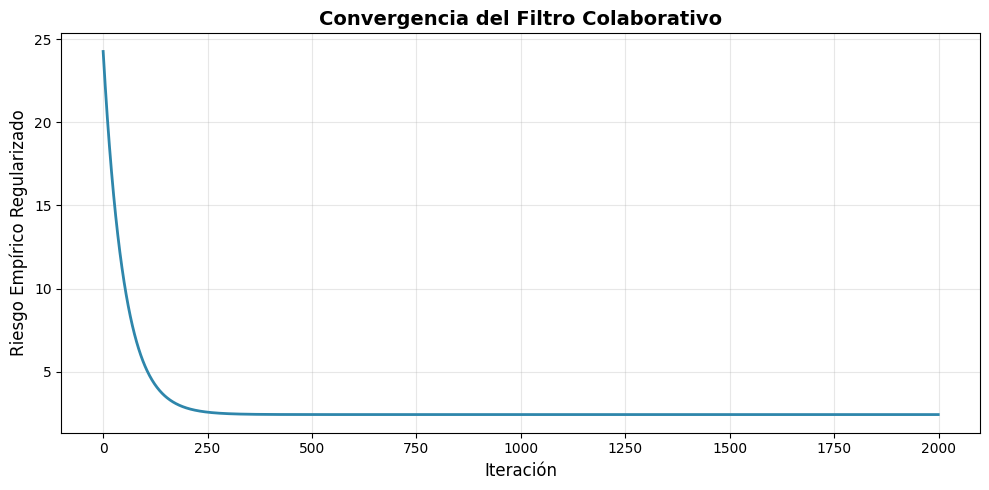

                                                       title  predicted_rating    cf_rating
                                            Infinite Stratos      1.414504e-19 2.829008e-19
                                             Yu-Gi-Oh! Arc-V      1.254927e-19 2.509854e-19
                                       Humanity Has Declined      1.214068e-19 2.428135e-19
             Ranking of Kings: The Treasure Chest of Courage      1.197258e-19 2.394516e-19
Nananin no Ayakashi: Chimi Chimi Mouryou!! Gendai Monogatari      1.183471e-19 2.366943e-19
                                                    Teekyu 4      1.145244e-19 2.290489e-19
                                               Shomin Sample      1.133758e-19 2.267516e-19
                             I★Chu: Halfway Through the Idol      1.107858e-19 2.215715e-19
                                                  Ochibi-san      1.087336e-19 2.174672e-19
                                      Non Non Biyori Nonstop      1.067891e-19 2

In [ ]:
# 1. Crear el buscador
buscador = AnimeBuscador(anime_path='/content/anime.csv')

# 2. Crear el sistema de recomendación
sistema = SistemaRecomendacion(buscador)

# b.2) Agregar usuario con al menos 10 series calificadas
mis_ratings = {
    'Attack on Titan': 10,
    'Death NOte': 9,
    'FullMetal Alchemist': 10,
    'Steins gate': 9,
    'One Punch Man': 8,
    'NaruTo': 7,
    'Dragon ball': 6,
    'COWBOY Bebop': 9,
    'Code Geass': 8,
    'Hunter Hunter': 9,
    'Tokyo Ghoul': 7,
    'Sword Art Online': 6
}

sistema.agregar_usuario(mis_ratings)

# b.3) Entrenar filtro colaborativo
sistema.entrenar(k=15, lambda_reg=10, lr=1e-3, iters=2000)

# Graficar convergencia
sistema.plot_loss()

# b.5) Obtener recomendaciones
recomendaciones = sistema.recomendar(n=10)
print(recomendaciones.to_string(index=False))